In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import seaborn as sns

In [2]:
dataset=pd.read_csv("C:\\Users\\Student.GROUP83-034\\Downloads\\loan_data_set.csv")

In [3]:
dataset.head(20)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [4]:
dataset.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
dataset.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [6]:
dataset.sample(20)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
64,LP001222,Female,No,0,Graduate,No,4166,0.0,116.0,360.0,0.0,Semiurban,N
119,LP001422,Female,No,0,Graduate,No,10408,0.0,259.0,360.0,1.0,Urban,Y
247,LP001819,Male,Yes,1,Not Graduate,No,6608,0.0,137.0,180.0,1.0,Urban,Y
219,LP001734,Female,Yes,2,Graduate,No,4283,2383.0,127.0,360.0,NaN,Semiurban,Y
316,LP002035,Male,Yes,2,Graduate,No,3717,0.0,120.0,360.0,1.0,Semiurban,Y
480,LP002534,Female,No,0,Not Graduate,No,4350,0.0,154.0,360.0,1.0,Rural,Y
529,LP002716,Male,No,0,Not Graduate,No,6783,0.0,130.0,360.0,1.0,Semiurban,Y
495,LP002586,Female,Yes,1,Graduate,No,3326,913.0,105.0,84.0,1.0,Semiurban,Y
562,LP002820,Male,Yes,0,Graduate,No,5923,2054.0,211.0,360.0,1.0,Rural,Y
347,LP002131,Male,Yes,2,Not Graduate,No,3083,2168.0,126.0,360.0,1.0,Urban,Y


In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [11]:
dataset.shape

(614, 13)

In [14]:
dataset.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [15]:
dataset.describe

<bound method NDFrame.describe of       Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001002    Male      No          0      Graduate            No   
1    LP001003    Male     Yes          1      Graduate            No   
2    LP001005    Male     Yes          0      Graduate           Yes   
3    LP001006    Male     Yes          0  Not Graduate            No   
4    LP001008    Male      No          0      Graduate            No   
..        ...     ...     ...        ...           ...           ...   
609  LP002978  Female      No          0      Graduate            No   
610  LP002979    Male     Yes         3+      Graduate            No   
611  LP002983    Male     Yes          1      Graduate            No   
612  LP002984    Male     Yes          2      Graduate            No   
613  LP002990  Female      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849        

In [24]:
dataset.describe(include='O')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [25]:
list(dataset.Gender.unique())

['Male', 'Female', nan]

In [26]:
list(dataset.Education.unique())

['Graduate', 'Not Graduate']

In [27]:
dataset.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [31]:
dataset['Gender']=dataset['Gender'].fillna(dataset['Gender'].mode().values[0])

In [32]:
dataset.isnull().sum()

Loan_ID               0
Gender                0
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [33]:
dataset['Married']=dataset['Married'].fillna(dataset['Married'].mode().values[0])

In [34]:
dataset.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [36]:
dataset['Dependents']=dataset['Dependents'].fillna(dataset['Dependents'].mode().values[0])

In [37]:
dataset.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [40]:
dataset['Self_Employed']=dataset['Self_Employed'].fillna(dataset['Self_Employed'].mode().values[0])

In [41]:
dataset.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [42]:
dataset['LoanAmount']=dataset['LoanAmount'].fillna(dataset['LoanAmount'].mode().values[0])

In [43]:
dataset.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [44]:
dataset['Loan_Amount_Term']=dataset['Loan_Amount_Term'].fillna(dataset['Loan_Amount_Term'].mode().values[0])

In [45]:
dataset.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [46]:
dataset['Credit_History']=dataset['Credit_History'].fillna(dataset['Credit_History'].mode().values[0])

In [47]:
dataset.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [50]:
dataset.drop('Loan_ID', axis=1, inplace=True)
#exploratory data analysis

In [51]:
dataset.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,120.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


<Axes: xlabel='count', ylabel='Gender'>

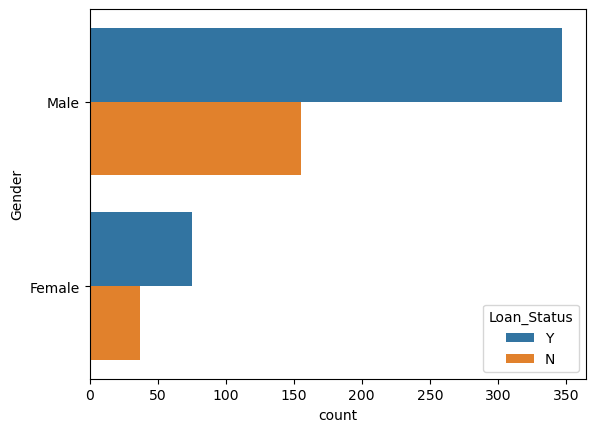

In [54]:
sns.countplot(y='Gender', hue='Loan_Status', data=dataset)

In [56]:
dataset['Gender'].value_counts()

Male      502
Female    112
Name: Gender, dtype: int64

<Axes: xlabel='count', ylabel='Married'>

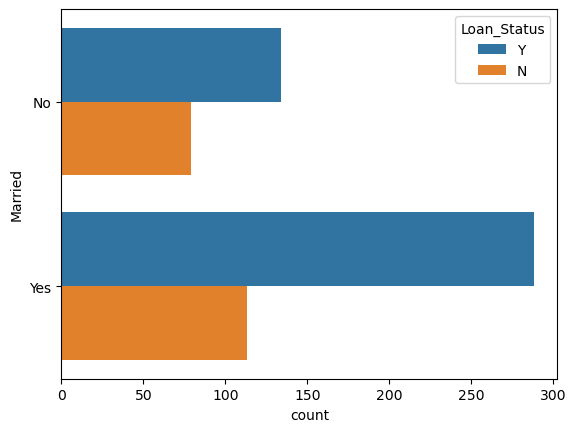

In [57]:
sns.countplot(y='Married', hue='Loan_Status', data=dataset)

In [58]:
dataset['Married'].value_counts()

Yes    401
No     213
Name: Married, dtype: int64

No     532
Yes     82
Name: Self_Employed, dtype: int64

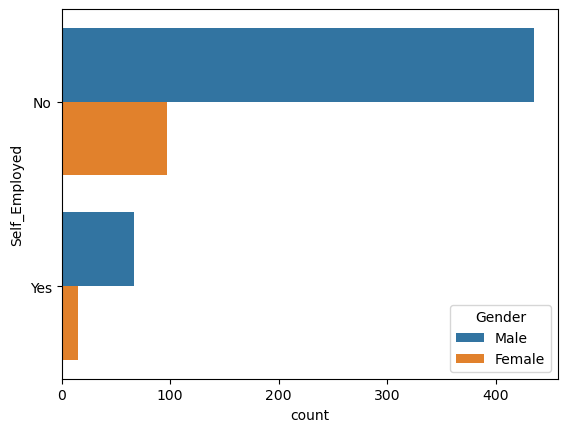

In [59]:
sns.countplot(y='Self_Employed', hue='Gender', data=dataset)
dataset['Self_Employed'].value_counts()

No     532
Yes     82
Name: Self_Employed, dtype: int64

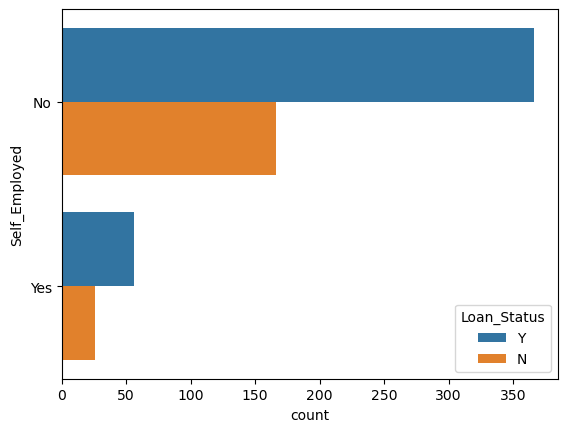

In [60]:
sns.countplot(y='Self_Employed', hue='Loan_Status', data=dataset)
dataset['Self_Employed'].value_counts()

Graduate        480
Not Graduate    134
Name: Education, dtype: int64

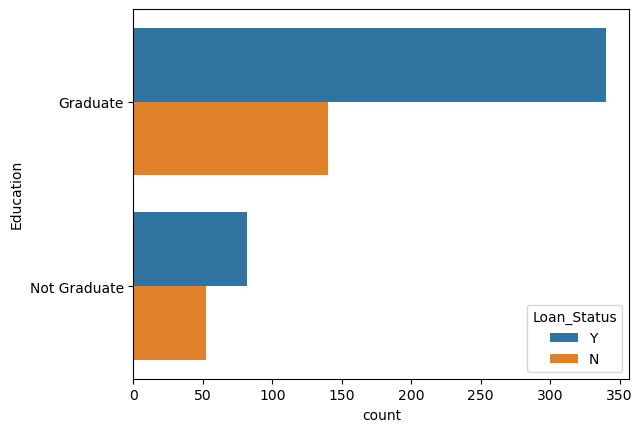

In [61]:
sns.countplot(y='Education', hue='Loan_Status', data=dataset)
dataset['Education'].value_counts()

In [65]:
gender={"Female": 0, "Male": 1}
dataset["Gender"]=dataset["Gender"].replace(gender)

In [66]:
dataset.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,No,0,Graduate,No,5849,0.0,120.0,360.0,1.0,Urban,Y
1,1,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,1,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,1,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,1,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [67]:
married={"No": 0, "Yes": 1}
dataset["Married"]=dataset["Married"].replace(married)

In [68]:
dataset.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,Graduate,No,5849,0.0,120.0,360.0,1.0,Urban,Y
1,1,1,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,1,1,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,1,1,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,1,0,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [69]:
education={"Not Graduate": 0, "Graduate": 1}
dataset["Education"]=dataset["Education"].replace(education)

In [70]:
dataset.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,1,No,5849,0.0,120.0,360.0,1.0,Urban,Y
1,1,1,1,1,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,1,1,0,1,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,1,1,0,0,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,1,0,0,1,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [71]:
self_employed={"No": 0, "Yes": 1}
dataset["Self_Employed"]=dataset["Self_Employed"].replace(self_employed)

In [73]:
dataset.head(20)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,1,0,5849,0.0,120.0,360.0,1.0,Urban,Y
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,Rural,N
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,Urban,Y
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,Urban,Y
5,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,1,1,0,0,0,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,1,1,3+,1,0,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,1,1,2,1,0,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,1,1,1,1,0,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [74]:
dependents={"0": 0, "1": 1, "3+": 3, "2": 2}
dataset["Dependents"]=dataset["Dependents"].replace(dependents)

In [75]:
dataset.head(20)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,1,0,5849,0.0,120.0,360.0,1.0,Urban,Y
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,Rural,N
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,Urban,Y
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,Urban,Y
5,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,1,1,0,0,0,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,1,1,3,1,0,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,1,1,2,1,0,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,1,1,1,1,0,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [76]:
property_area={"Urban": 1, "Rural": 2, "Semiurban": 3}
dataset["Property_Area"]=dataset["Property_Area"].replace(property_area)

In [77]:
dataset.head(20)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,1,0,5849,0.0,120.0,360.0,1.0,1,Y
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,2,N
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,Y
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,Y
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,Y
5,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,1,Y
6,1,1,0,0,0,2333,1516.0,95.0,360.0,1.0,1,Y
7,1,1,3,1,0,3036,2504.0,158.0,360.0,0.0,3,N
8,1,1,2,1,0,4006,1526.0,168.0,360.0,1.0,1,Y
9,1,1,1,1,0,12841,10968.0,349.0,360.0,1.0,3,N


In [78]:
loan_status={"N": 0, "Y": 1}
dataset["Loan_Status"]=dataset["Loan_Status"].replace(loan_status)

In [81]:
dataset.head(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,1,0,5849,0.0,120.0,360.0,1.0,1,1
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,2,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,1
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,1
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,1
5,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,1,1
6,1,1,0,0,0,2333,1516.0,95.0,360.0,1.0,1,1
7,1,1,3,1,0,3036,2504.0,158.0,360.0,0.0,3,0
8,1,1,2,1,0,4006,1526.0,168.0,360.0,1.0,1,1
9,1,1,1,1,0,12841,10968.0,349.0,360.0,1.0,3,0


In [83]:
x=dataset.drop("Loan_Status", 1)
y=dataset.Loan_Status

C:\Users\Student.GROUP83-034\AppData\Local\Temp\ipykernel_11140\2281023582.py:1: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  x=dataset.drop("Loan_Status", 1)


In [85]:
#split
#fromsklearn - splitting data array into 2 i.e training and splitting
#randomstate control the shaffling applied to the data
#stratify is to let us know whether we want to retain the training and the testing
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=38, stratify=y)

In [102]:
from sklearn.neighbors import KNeighborsClassifier#importing knn algorithms
knn=KNeighborsClassifier(n_neighbors=5) #look at least eucleadian distance from the 5 

In [103]:
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [104]:
prediction_knn=knn.predict(x_test)
print("prediction for test set: {}".format(prediction_knn))

prediction for test set: [1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1
 1 1 1 1 0 1 1 0 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 0 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1
 1 1 1 0 1 1]


In [105]:
a=pd.DataFrame({'actual value': y_test, 'predicted value':prediction_knn})

In [106]:
a.head()

,actual value,predicted value
263,1,1
395,1,1
226,0,0
413,1,1
403,1,0


In [107]:
from sklearn import metrics 
from sklearn.metrics import classification_report, confusion_matrix

In [108]:
matrix=confusion_matrix(y_test, prediction_knn)

<Axes: >

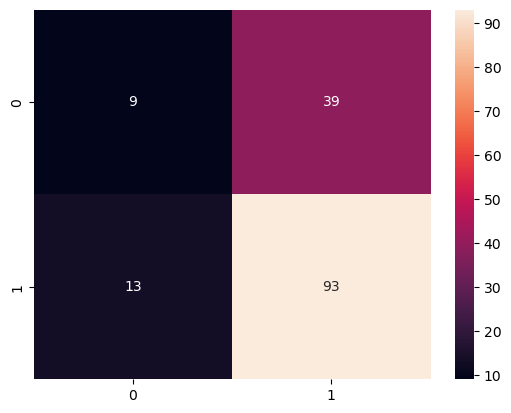

In [109]:
sns.heatmap(matrix, annot=True, fmt="d")

In [110]:
print(classification_report(y_test, prediction_knn))

              precision    recall  f1-score   support

           0       0.41      0.19      0.26        48
           1       0.70      0.88      0.78       106

    accuracy                           0.66       154
   macro avg       0.56      0.53      0.52       154
weighted avg       0.61      0.66      0.62       154

